In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv("/content/drive/MyDrive/loan_risk_prediction_dataset.csv")
df.head(30)


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1
6,38,54748.0,25374.0,760.0,9,Female,High School,New York,Self-Employed,1
7,56,NaN,6279.0,599.0,22,Male,PhD,New York,Unemployed,0
8,36,25918.0,25041.0,777.0,29,Female,Bachelors,San Francisco,Unemployed,0
9,40,43415.0,2065.0,382.0,30,Female,High School,San Francisco,Self-Employed,0


In [21]:
# checking the structure and the info about the data before analysis
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [55]:
# Remove negative loan amounts
df = df[df["LoanAmount"] > 0]

# Remove negative income values
df = df[df["Income"] > 0]

# Drop null values if any
df = df.dropna()

# Drop duplicates if any
df = df.drop_duplicates()

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (4401, 10)


In [7]:
# checking null values and cleaning the data
df.isnull().sum()


,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [13]:
# checking the duplicate data in dataset
df.duplicated().sum()



,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [10]:
df["LoanApproved"].value_counts() # checking the amount of loan approved and disapproved in dataset

,count
LoanApproved,
0,3849
1,1151


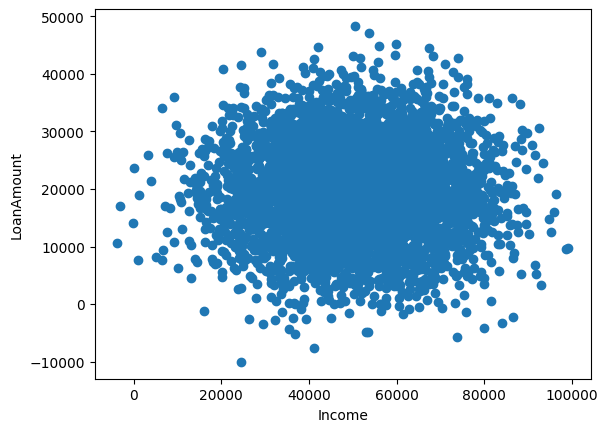

In [57]:
import matplotlib.pyplot as plt

plt.scatter(df["Income"], df["LoanAmount"])
plt.xlabel("Income")
plt.ylabel("LoanAmount")
plt.show()

The scatter plot shows no strong linear relationship between applicant income and requested loan amount. Most applicants fall within an income range of 30,000–70,000 and request loans between 10,000–30,000. The wide dispersion of points suggests that income alone does not explain variations in loan amount. A few unrealistic negative loan amounts were identified as potential outliers that should be addressed during data cleaning.


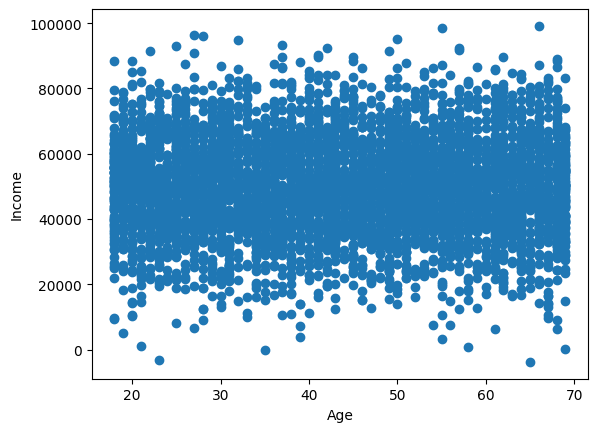

In [58]:
plt.scatter(df['Age'],df['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

The scatter plot indicates that there is no strong relationship between an applicant's age and income. Income levels are spread across all age groups, suggesting that age alone is not a reliable predictor of income. A few potential outliers with unusually low or negative income values were observed and should be examined during data preprocessing.


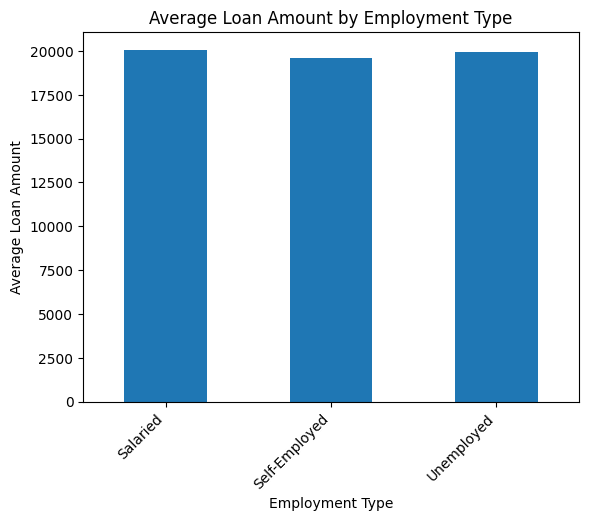

In [72]:
avg_loan = df.groupby("EmploymentType")["LoanAmount"].mean()

avg_loan.plot(kind="bar")
plt.xlabel("Employment Type")
plt.ylabel("Average Loan Amount")
plt.title("Average Loan Amount by Employment Type")
plt.xticks(rotation=45, ha="right")
plt.show()

The analysis shows that the average loan amount requested is nearly the same across Salaried, Self-Employed, and Unemployed applicants, with values close to 20,000. Although Salaried applicants have a slightly higher average loan amount, the differences are negligible. This suggests that employment type, by itself, is not a strong factor in determining the requested loan amount.


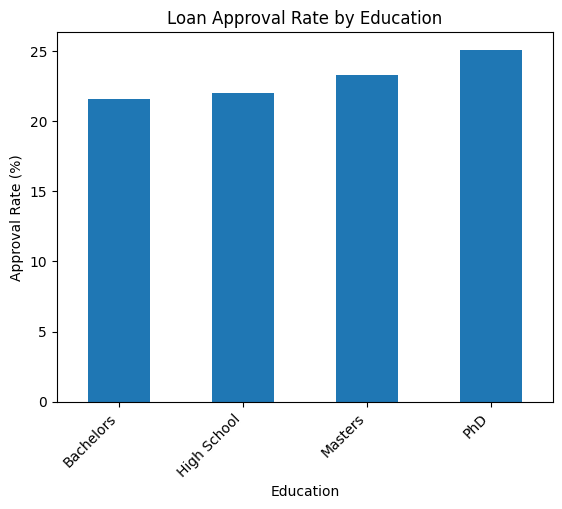

In [71]:
approval = df.groupby("Education")["LoanApproved"].mean() * 100

approval.plot(kind="bar")
plt.ylabel("Approval Rate (%)")
plt.title("Loan Approval Rate by Education")
plt.xticks(rotation=45, ha="right")
plt.show()


given the graph which shows a clear upward trend where higher levels of education generally correlate with higher loan approval percentages. Individuals with a PhD achieve the highest approval rate at just over 25%, followed closely by those with a Masters degree at approximately 23.5%. Conversely, the lowest approval rates are seen at the undergraduate level, with individuals holding a Bachelors degree experiencing the lowest rate at roughly 21.5%, sitting just slightly below the High School cohort's rate of about 22%.

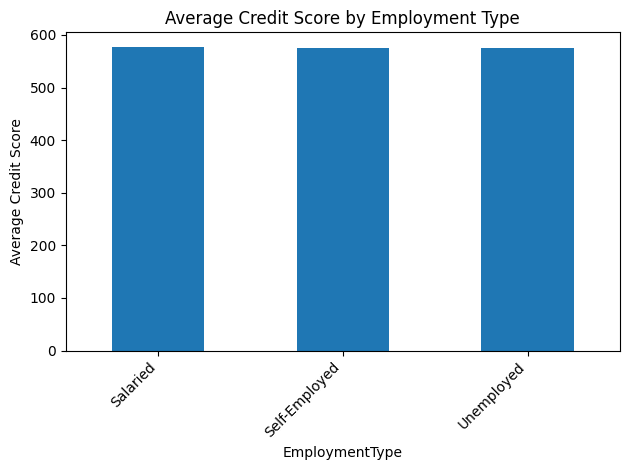

In [69]:
credit = df.groupby("EmploymentType")["CreditScore"].mean()

credit.plot(kind="bar")
plt.ylabel("Average Credit Score")
plt.title("Average Credit Score by Employment Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

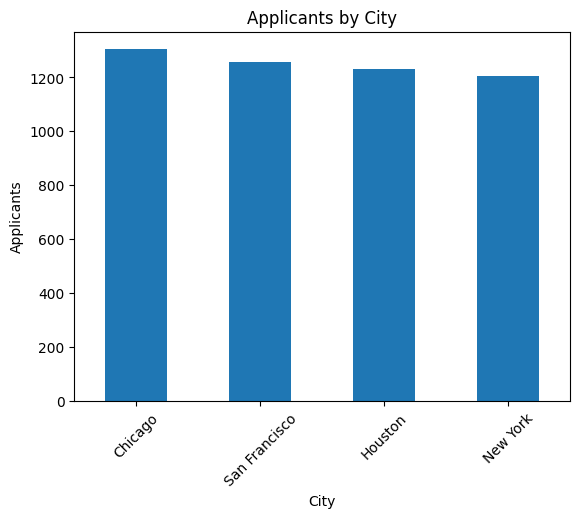

In [64]:
import matplotlib.pyplot as plt

df["City"].value_counts().plot(kind="bar")

plt.xlabel("City")
plt.ylabel("Applicants")
plt.title("Applicants by City")

plt.xticks(rotation=45)  s

plt.show()

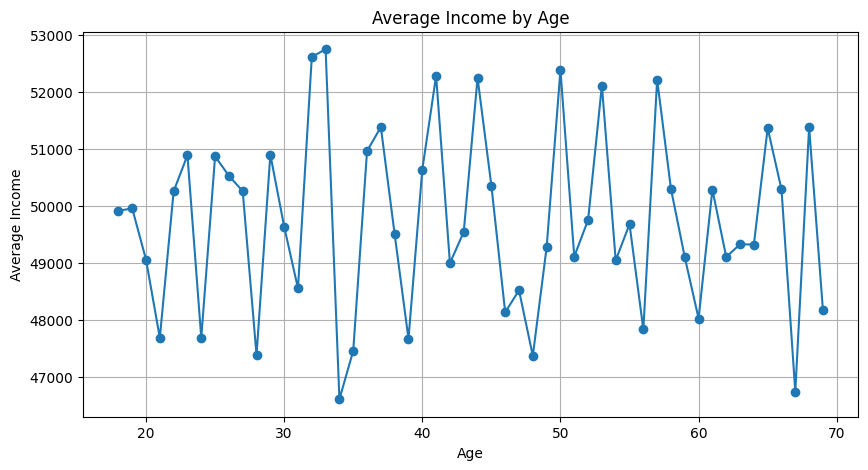

In [74]:
avg_income = df.groupby("Age")["Income"].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_income.index, avg_income.values, marker='o')
plt.xlabel("Age")
plt.ylabel("Average Income")
plt.title("Average Income by Age")
plt.grid(True)
plt.show()

The chart shows Average Income by Age ranging from roughly $47,000 to $53,000 across ages 18 - 70. There is no clear upward or downward trend — income fluctuates randomly throughout all age groups. Notable peaks appear around ages 32, 40, and 50, while the sharpest dips occur near ages 34 and 68. The high volatility between adjacent ages suggests either a synthetic dataset or significant uncontrolled variables. Overall, income remains relatively flat across the entire age range.


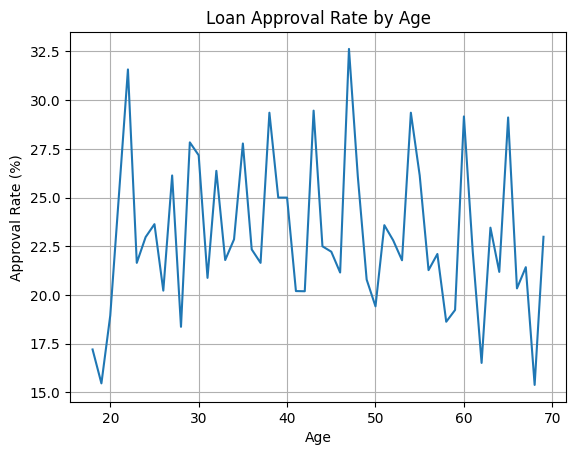

In [32]:
approval_rate = df.groupby("Age")["LoanApproved"].mean() * 100

plt.plot(approval_rate.index, approval_rate.values)
plt.xlabel("Age")
plt.ylabel("Approval Rate (%)")
plt.title("Loan Approval Rate by Age")
plt.grid(True)
plt.show()

The chart shows Approval Rate (%) by Age ranging from roughly 15% to 33% across ages 18-70. There is no consistent trend — approval rates fluctuate heavily throughout all age groups with no clear peak or decline phase. The highest approval rate appears around age 46 ~32.5%, while the lowest dips occur near ages 18 and 68 i.e. ~15-16%. The extreme volatility between adjacent ages suggests high variability with no strong age-based pattern. Overall, approval rates hover mostly between 20-29% for the majority of the age range.

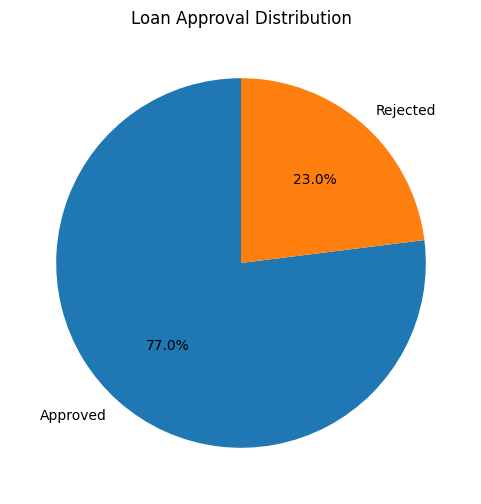

In [37]:
loan_counts = df["LoanApproved"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    loan_counts,
    labels=["Approved", "Rejected"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Loan Approval Distribution")
plt.show()

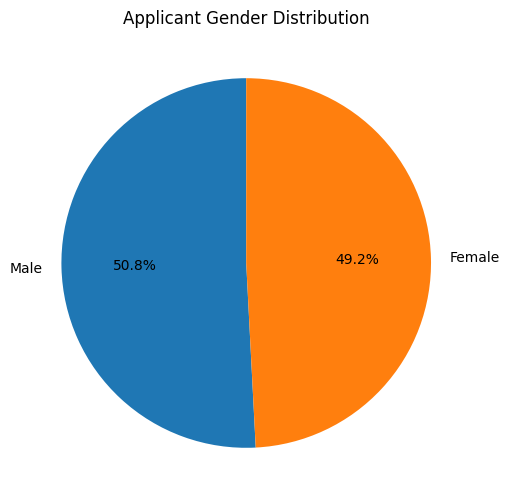

In [38]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Applicant Gender Distribution")
plt.show()

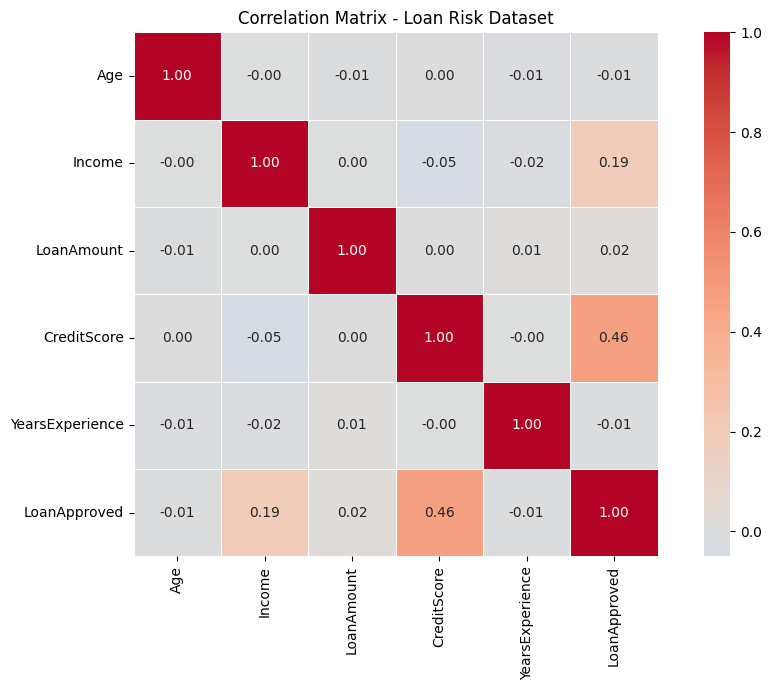

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Select only numeric columns ──────────────────────────────────────────
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# ── 2. Correlation Matrix Heatmap ───────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix - Loan Risk Dataset")
plt.tight_layout()
plt.show()

1.00 means a perfect positive correlation (as one goes up, the other goes up).

-1.00 means a perfect negative correlation (as one goes up, the other goes down).

0.00 means no linear relationship at all.

The heatmap reveals that CreditScore is the strongest predictor of loan approval with a correlation of 0.46, indicating that applicants with higher credit scores are significantly more likely to get approved. Income shows a moderate positive correlation of 0.19 with loan approval, suggesting it plays a secondary role in the decision. All other features — Age, LoanAmount, and YearsExperience — show near-zero correlations with loan approval, meaning they have little to no linear influence on the outcome. Overall, the dataset suggests that creditworthiness and income are the two key drivers of loan approval, while demographic and experience factors appear largely irrelevant in this dataset.

In [54]:
#  Observation
print("Top features correlated with Loan Approval:\n")
print(loan_corr.abs().sort_values(ascending=False))

Top features correlated with Loan Approval:

CreditScore        0.464790
Income             0.190897
LoanAmount         0.018302
Age                0.008754
YearsExperience    0.006372
Name: LoanApproved, dtype: float64


#conclusion



This exploratory data analysis was conducted on a loan risk prediction dataset to identify key factors influencing loan approval decisions.
The analysis revealed that CreditScore is the single strongest predictor of loan approval (correlation: 0.46), followed by Income (0.19) as a secondary factor. All other numeric features — Age, LoanAmount, and YearsExperience — showed near-zero correlation with loan approval, suggesting they have minimal linear influence on the outcome.
From the categorical analysis, Education level showed a mild upward trend, with PhD holders achieving the highest approval rate (25%) compared to Bachelor's degree holders (21.5%). Employment type had a negligible effect on both average loan amount and credit score across Salaried, Self-Employed, and Unemployed applicants.
The gender distribution and city-wise applicant spread appeared fairly balanced, with no single group dominating the dataset. The overall loan approval rate was also relatively balanced between approved and rejected applications.
In summary, a loan applicant's credit score and income are the most critical factors in determining approval, while demographic variables such as age, gender, and city appear to have little impact. Future work could involve building a predictive model (e.g., Logistic Regression or Random Forest) using these insights to automate and improve loan approval decisions.